### High-level setup

In [1]:
USE_COLAB = False
FFD_SCALE = 3.0
MI_ESTIMATOR = "DC"
DISCREPANCY = "JSD"
USE_CUDA = False
NDE_NET = 'MAF'

### Run it in case of using Colab servers

In [2]:
import sys
from google.colab import drive
!rm -rf LiFIMI_Attack
!git clone https://github.com/Vegnics/LiFIMI_Attack.git
sys.path.append("./LiFIMI_Attack")
DIR = 'results/FFD'
drive.mount('/content/drive')
!cp -r /content/drive/MyDrive/SimpleFace ./
IMG_FOLDER = "/content/SimpleFace"
OUT_FOLDER = "/content/out_folder"

ModuleNotFoundError: No module named 'google'

In [2]:
import os, sys, inspect, time
"""
solve the conflict between paths, and work dir
"""
sys.path.append('../')
os.chdir('../')
print(sys.path)
print(os.getcwd())

import numpy as np
import torch 
import matplotlib.pyplot as plt
torch.multiprocessing.set_sharing_strategy('file_system')

import lfi
from lfi.utils import discrepancy, visualization
from lfi.algorithms import ABC_algorithms, SMCABC, SMC2ABC, SNLABC, SNL2ABC
from lfi.detsimul import problem_FFD,problem_FFD_image
from lfi.utils import uos, umath

['/home/amaranth2/miniconda3/envs/itcff/lib/python311.zip', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11/lib-dynload', '', '/home/amaranth2/miniconda3/envs/itcff/lib/python3.11/site-packages', '../']
/home/amaranth2/ITC_FF


/home/amaranth2/ITC_FF/images_test/pacquiao_front.jpg
/home/amaranth2/ITC_FF/images_test/ledecky_front.jpg
[True posterior] pilot run 
finished pilot run: 200
finished pilot run: 400
finished pilot run: 600
finished pilot run: 800
finished pilot run: 1000
finished pilot run: 1200
finished pilot run: 1400
finished pilot run: 1600
finished pilot run: 1800
finished pilot run: 2000
finished pilot run: 2200
finished pilot run: 2400
finished pilot run: 2600
finished pilot run: 2800
finished pilot run: 3000
finished pilot run: 3200
finished pilot run: 3400
finished pilot run: 3600
finished pilot run: 3800
finished pilot run: 4000
finished pilot run: 4200
finished pilot run: 4400
finished pilot run: 4600
finished pilot run: 4800
finished pilot run: 5000
finished pilot run: 5200
finished pilot run: 5400
finished pilot run: 5600
finished pilot run: 5800
finished pilot run: 6000
finished pilot run: 6200
finished pilot run: 6400
finished pilot run: 6600
finished pilot run: 6800
finished pilot run:

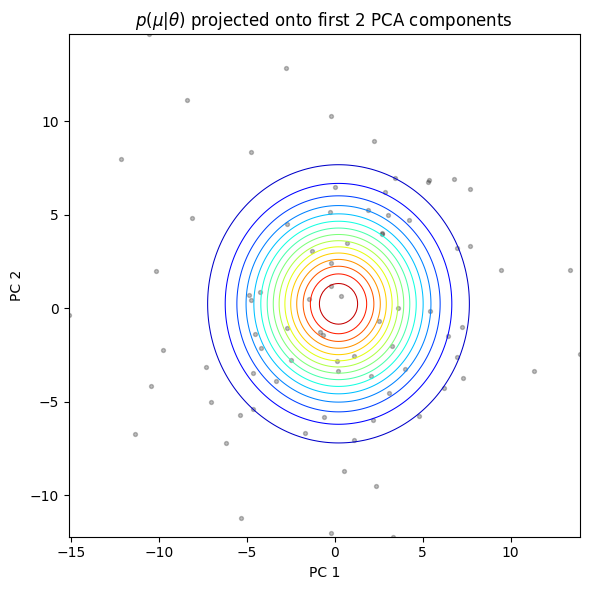

mean-parma1 =  -0.01819736166457693      mean-param2 =  10.771896956615858


<Figure size 500x400 with 0 Axes>

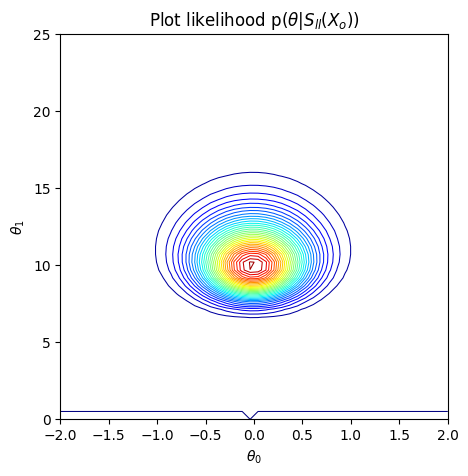

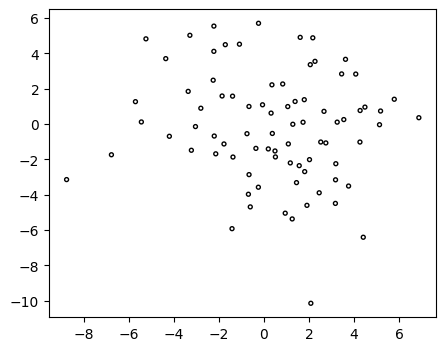

In [3]:
DIR = 'results/FFD' 
#IMG_FOLDER = "/home/amaranth2/Downloads/SimpleFace"
#IMG_FOLDER = os.path.join("/home/quinoa/LiFIMI_Attack","images_test")
IMG_FOLDER = os.path.join("/home/amaranth2/ITC_FF","images_test")
OUT_FOLDER = "/home/quinoa/out_folder"
problem = problem_FFD_image.FFD_Image_Problem(N=200, n=80)
problem.img_folder = IMG_FOLDER
problem.out_img_folder = OUT_FOLDER
problem.true_mean = 0.0
problem.true_var = 10.0
# Get images for experiments
#try:
#    os.mkdir("img_temp")
#except:
#    pass
#uos.download_image("https://i.ibb.co/1fhbrR7X/ledecky-front.jpg","img_temp/ledecky.jpg")
#uos.download_image("https://i.ibb.co/HTmfq9LF/pacquiao-front.jpg","img_temp/pacquiao.jpg")
#!curl -o ./img_temp/ledecky.jpg https://i.ibb.co/1fhbrR7X/ledecky-front.jpg
#!curl -o ./img_temp/pacquiao.jpg https://i.ibb.co/HTmfq9LF/pacquiao-front.jpg
problem.get_work_imgs()
!rm -rf img_temp

true_theta = problem.get_true_theta()
## FFD parameter scale
problem.ffd_scale = FFD_SCALE

## The simulator returns the observed mu params and 
## the deformed images
problem.data_obs, problem.imgs_obs = problem.simulator(true_theta)
## Compute PCA over the observed data
problem.compute_pca(n_components=15)
## Pick a mu param
#problem.y_obs, problem.imgs_obs = problem.statistics(data=problem.data_obs,images=problem.imgs_obs, theta=true_theta)
problem.y_obs, _ = problem.statistics(data=problem.data_obs,images=problem.imgs_obs, theta=true_theta)

## Sample thetas from the true posterior
true_samples = problem.sample_from_true_posterior()
## Get the true theta
theta_true = problem.get_true_theta()

## Visualize the likelihood of the samples p(x|theta)
problem.visualize()
plt.figure(figsize=(5,4))
visualization.plot_likelihood(samples=true_samples,
                              log_likelihood_function=problem.log_likelihood,
                              dimensions=(0,1),
                              bounded = False,
                              xmin = -2.0,
                              xmax = 2.0,
                              ymin = 0.0,
                              ymax = 25.0)
plt.show()
visualization.plot_samples(problem.data_obs)
#uos.save_object(DIR, 'true_samples', true_samples)

### Visualize warped images

Plotting original images


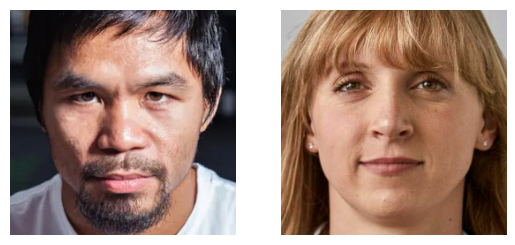

Plotting warped images


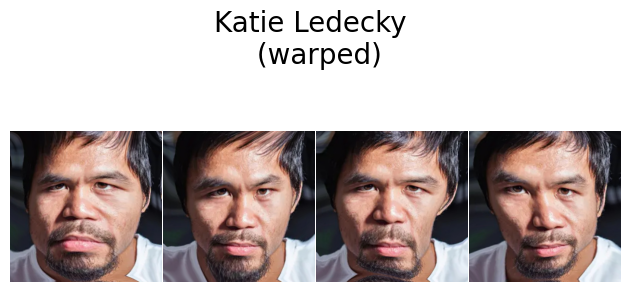

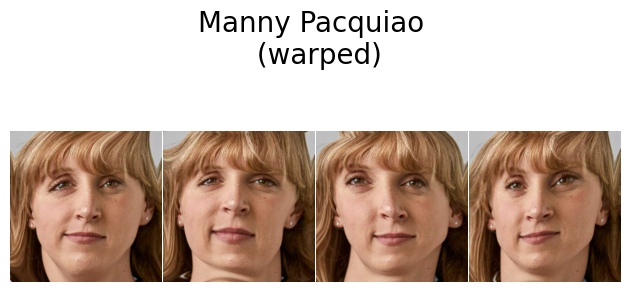

In [4]:
# Original images
print("Plotting original images")
figs,axes = plt.subplots(1,len(problem.work_imgs))
for k,img in enumerate(problem.work_imgs):
    axes[k].imshow(img[:,:,::-1])
    axes[k].set_axis_off()
plt.show()

print("Plotting warped images")
imgs = problem.imgs_obs
imgs_1 = imgs[0:4]
figs,axes = plt.subplots(1,4)
figs.suptitle('Katie Ledecky \n (warped)', fontsize=20, y=0.92)
#figs.tight_layout(rect=[0, 0, 1, 0.9])
for i in range(4):
    axes[i].imshow(imgs_1[i][:,:,::-1])
    axes[i].set_axis_off()
figs.tight_layout()
plt.subplots_adjust(top=0.99,wspace=0.01)
plt.show()

imgs_2 = imgs[imgs.shape[0]//2+1:imgs.shape[0]//2+5]
figs,axes = plt.subplots(1,4)
figs.suptitle('Manny Pacquiao \n (warped)', fontsize=20, y=0.92)
#plt.tight_layout()
for i in range(4):
    axes[i].imshow(imgs_2[i][:,:,::-1])
    axes[i].set_axis_off()
figs.tight_layout()
plt.subplots_adjust(top=0.99,wspace=0.01)
plt.show()

In [ ]:
## Sequential Neural Likelihood
hyperparams = ABC_algorithms.Hyperparams()
hyperparams.save_dir = DIR
hyperparams.device = 'cuda:0' if USE_CUDA else 'cpu'
hyperparams.num_sim = 100#4000                   # number of sampling/simulation rounds
hyperparams.L = 4                                # number of learning rounds
hyperparams.type = 'cnnimg'
hyperparams.stat = 'infomax'                     # statistics function: infomax/moment/score  

#Hyperparameters for StatNet
hyperparams.n_neg = 5
hyperparams.bs = 32
hyperparams.lr = 2.0e-4

hyperparams.estimator = MI_ESTIMATOR                     # MI estimator; JSD (accurate) or DC (fast)
hyperparams.nde = NDE_NET                         # nde; MAF (D>1) or MDN (D=1)
from lfi.utils import discrepancy, visualization

print('\n SNL ABC')
print(f"Imgs observed: {problem.imgs_obs.shape}")
problem.n = 2 # Number of image simulations (only one is chosen)
snl_abc = SNL2ABC.SNL2_ABC_Image(problem, discrepancy=discrepancy.eculidean_dist, hyperparams=hyperparams)
snl_abc.run()

JSD_array = []
for l in range(len(snl_abc.nde_array)):
    print('Iteration: ', l+1)
    snl_abc.nde_net = snl_abc.nde_array[l]
    visualization.plot_likelihood(samples=true_samples, log_likelihood_function=snl_abc.log_likelihood, dimensions=(0,1),bounded=False)
    plt.show()
    JSD = discrepancy.JSD(problem.log_likelihood, snl_abc.log_likelihood, true_samples, true_samples, N_grid=30)
    JSD_array.append(JSD)
    print('JSD snl = ', JSD)
#uos.save_object(DIR, 'JSD_SNL', JSD_array)


 SNL ABC
Imgs observed: (160, 256, 256, 3)
iteration  0
[sampling] finished sampling  5
[sampling] finished sampling  10
[sampling] finished sampling  15


KeyboardInterrupt: 